# Atomic Fact Necessity — Sharechat

Explores `results/sharechat/atomic_fact_necessity.csv`: which atomic facts are **essential** vs **non-essential** to answering each question, and how that breaks down by model, search usage, and entropy.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import textwrap

pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.dpi'] = 120

CSV = '../results/sharechat/atomic_fact_necessity.csv'
df = pd.read_csv(CSV)
df['is_essential'] = df['is_essential'].astype(str).str.strip().str.lower() == 'true'

print(f"Rows: {len(df):,}  |  Questions: {df['problem'].nunique()}  |  Models: {df['model'].unique().tolist()}")
df.head(3)

Rows: 4,072  |  Questions: 169  |  Models: ['nemotron-3-nano', 'gemini-3-pro-preview']


,model,problem,has_search,search_calls,atomic_fact,attributed_to_search,reasoning,sampler_response,paraphrased_question,sample_1,sample_2,sample_3,sample_4,sample_5,num_clusters,cluster_sizes,entropy,is_essential,necessity_reasoning
0,nemotron-3-nano,The effects of having adhd & anxiety and not being able to take your medicine while tortured,False,0,The stress of torture can lead to severe emotional dysregulation in unmedicated individuals with ADHD and anxiety.,False,No search results available for this query.,"When a person with ADHD and anxiety cannot take their medication during torture, untreated symptoms often become mar...",Does the stress of torture cause severe emotional dysregulation in unmedicated individuals with ADHD and anxiety?,"Yes, torture‑related stress can severely exacerbate emotional dysregulation in untreated ADHD‑with‑anxiety individuals.",Yes. Severe stress such as torture can intensify emotional dysregulation in unmedicated individuals with ADHD and an...,Yes.,Yes.,"Yes, stress from torture can provoke severe emotional dysregulation in unmedicated individuals with ADHD and anxiety.",1,[5],0.0,True,This fact identifies a primary psychological effect (emotional dysregulation) directly resulting from the combinatio...
1,nemotron-3-nano,How to install ffmpeg on a n8n docker instance using custom dockerfile,True,1,"To add FFmpeg to an n8n Docker image, the official n8nio/n8n image can be used as a base.",True,Search result [4] provides a Dockerfile example that uses 'FROM n8nio/n8n' as a base image and then installs FFmpeg.,"To add FFmpeg to an n8n Docker image, start from the official n8n base (e.g. `n8nio/n8n:latest`) and use an Alpine‑b...",Can the official n8nio/n8n Docker image be used as a base to add FFmpeg to an n8n Docker image?,Yes.,"Yes – you can extend the official n8nio/n8n image and add ffmpeg (e.g., via apt‑get).",Yes,Yes,"Yes, you can build on the official `n8nio/n8n` image and install FFmpeg in your Dockerfile.",1,[5],0.0,True,Defining a base image using the FROM instruction is a required and foundational component of creating any custom Doc...
2,gemini-3-pro-preview,What is the relationship between the invention of time and numbers and letters? \n\n\nSpecifically : \n\nHow the in...,False,0,The invention of numbers stems from the shift toward symbolic abstraction.,False,No search results available for this query.,"The invention of numbers, written language, calendars, and money all stem from humanity's profound shift toward symb...",What conceptual shift led to the invention of numbers?,The abstraction of quantity from physical objects.,The abstraction of quantity from physical objects.,The abstraction of quantity from concrete objects.,The abstraction of quantity.,The abstraction of quantity from concrete objects.,1,[5],0.0,True,This fact explains the cognitive foundation that allowed for the quantification and symbolic representation of abstr...


## 1. Overall essential vs non-essential split

is_essential
Essential        2437
Non-essential    1635

Essential rate: 59.8%


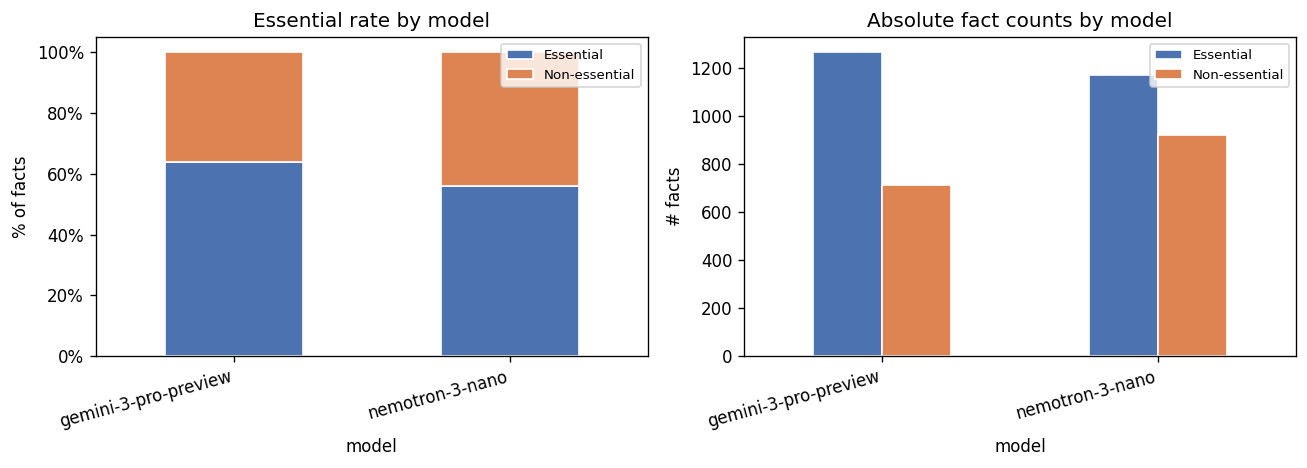

In [2]:
overall = df['is_essential'].value_counts().rename({True: 'Essential', False: 'Non-essential'})
print(overall.to_string())
print(f"\nEssential rate: {overall['Essential'] / overall.sum():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Stacked bar by model
by_model = df.groupby(['model', 'is_essential']).size().unstack(fill_value=0)
by_model.columns = ['Non-essential', 'Essential']
by_model_pct = by_model.div(by_model.sum(axis=1), axis=0) * 100
by_model_pct[['Essential', 'Non-essential']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#4C72B0', '#DD8452'], edgecolor='white'
)
axes[0].set_title('Essential rate by model')
axes[0].set_ylabel('% of facts')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].legend(loc='upper right', fontsize=8)

# Absolute counts
by_model[['Essential', 'Non-essential']].plot(
    kind='bar', ax=axes[1],
    color=['#4C72B0', '#DD8452'], edgecolor='white'
)
axes[1].set_title('Absolute fact counts by model')
axes[1].set_ylabel('# facts')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 2. Facts per question — distribution

       essential  non_essential   total  essential_rate
count     336.00         336.00  336.00          336.00
mean        7.25           4.87   12.12            0.60
std         5.28           3.65    6.57            0.24
min         0.00           0.00    1.00            0.00
25%         4.00           2.00    9.00            0.44
50%         7.00           4.00   11.00            0.62
75%        10.00           7.00   14.00            0.77
max        71.00          31.00  102.00            1.00


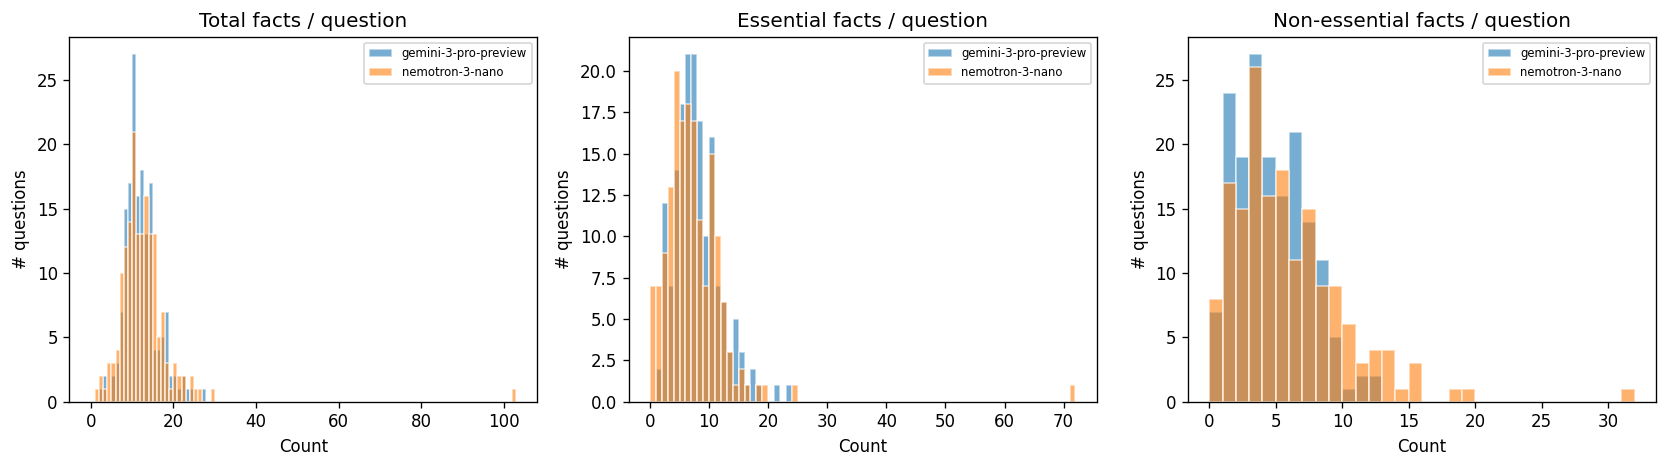

In [3]:
per_q = (
    df.groupby(['problem', 'model', 'has_search'])['is_essential']
    .agg(essential='sum', total='count')
    .reset_index()
)
per_q['non_essential'] = per_q['total'] - per_q['essential']
per_q['essential_rate'] = per_q['essential'] / per_q['total']

print(per_q[['essential', 'non_essential', 'total', 'essential_rate']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label, color in [
    (axes[0], 'total',         'Total facts / question',       '#555'),
    (axes[1], 'essential',     'Essential facts / question',   '#4C72B0'),
    (axes[2], 'non_essential', 'Non-essential facts / question','#DD8452'),
]:
    for model, grp in per_q.groupby('model'):
        ax.hist(grp[col], bins=range(0, per_q[col].max() + 2), alpha=0.6, label=model, edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('Count')
    ax.set_ylabel('# questions')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 3. Essential rate per question — sorted heatmap

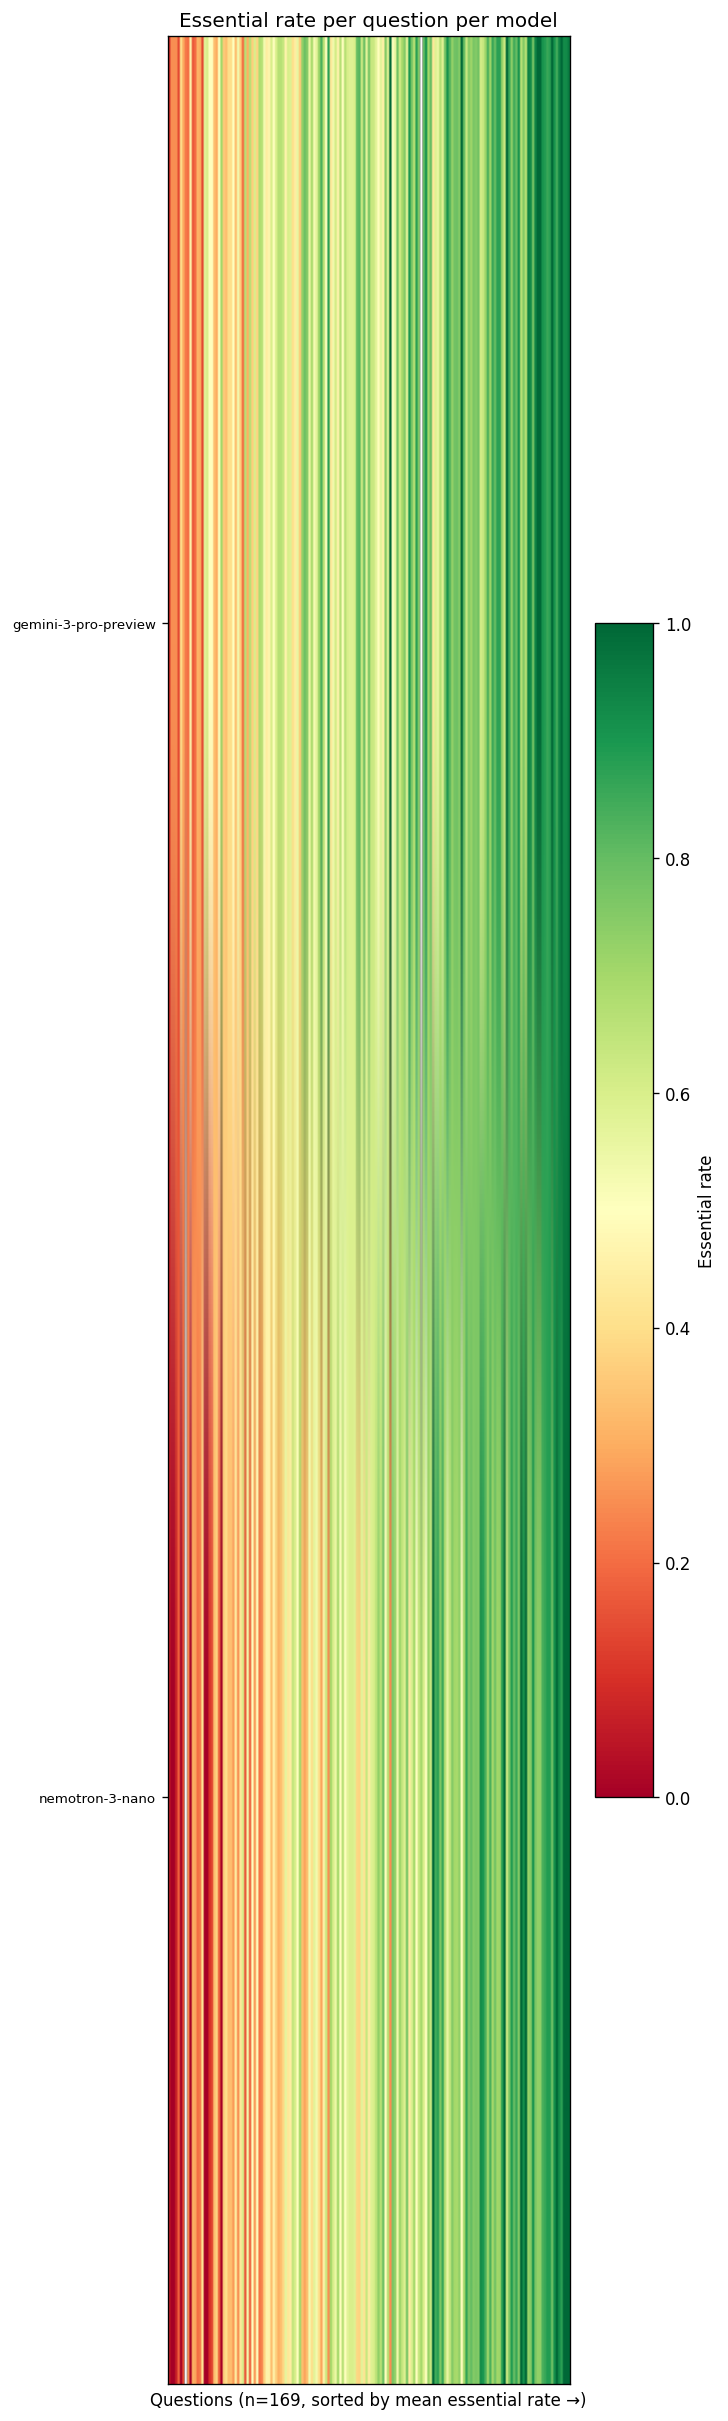

In [4]:
# Pivot: one row per question, one column per model
rate_pivot = per_q.pivot_table(
    index='problem', columns='model', values='essential_rate'
)

# Sort by mean essential rate
rate_pivot = rate_pivot.assign(mean=rate_pivot.mean(axis=1)).sort_values('mean').drop(columns='mean')

fig, ax = plt.subplots(figsize=(6, max(4, len(rate_pivot) * 0.12)))
im = ax.imshow(rate_pivot.values.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_yticks(range(len(rate_pivot.columns)))
ax.set_yticklabels(rate_pivot.columns, fontsize=8)
ax.set_xticks([])
ax.set_xlabel(f'Questions (n={len(rate_pivot)}, sorted by mean essential rate →)')
ax.set_title('Essential rate per question per model')
plt.colorbar(im, ax=ax, label='Essential rate', shrink=0.5)
plt.tight_layout()
plt.show()

## 4. Essential rate vs search usage

/tmp/ipykernel_7733/3922824485.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=['No search', 'Search'], patch_artist=True,
/tmp/ipykernel_7733/3922824485.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=['No search', 'Search'], patch_artist=True,


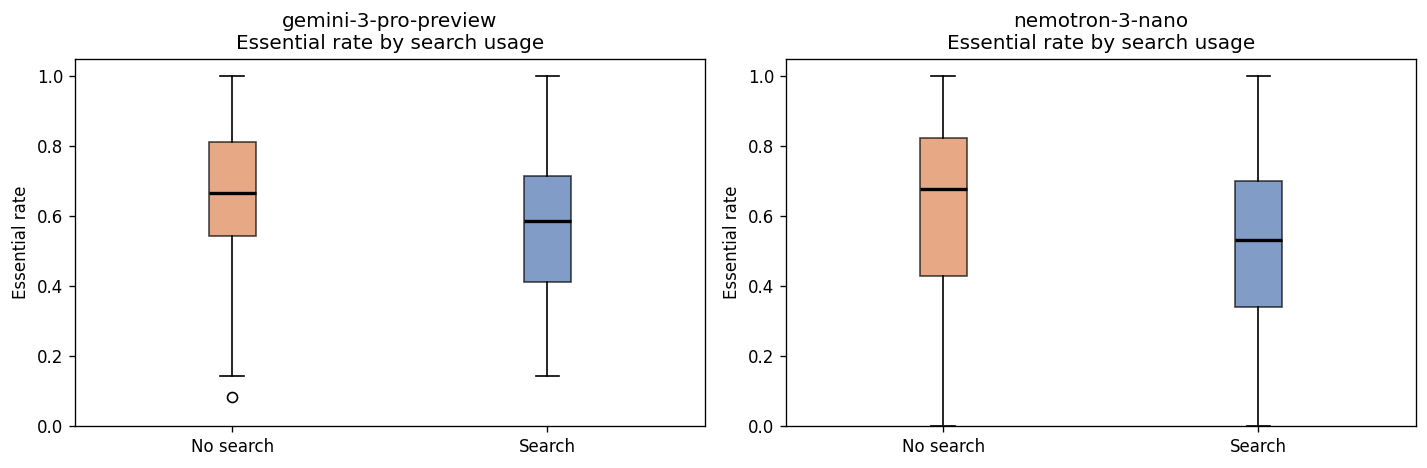

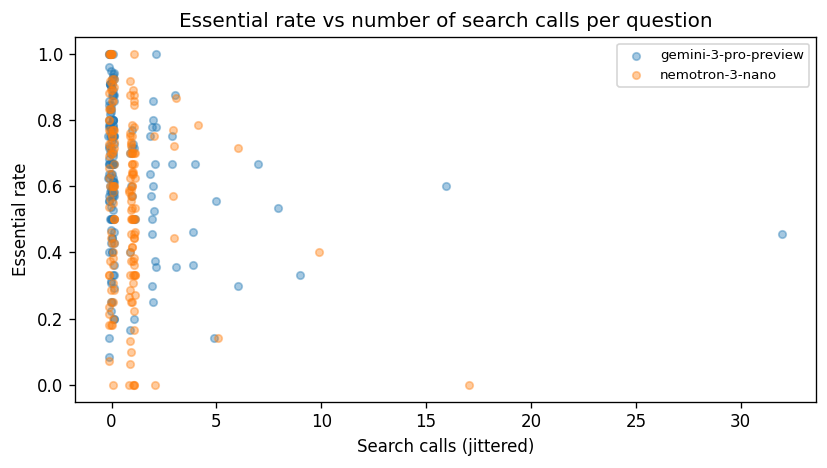

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box: search vs no-search
for i, (ax, model) in enumerate(zip(axes, per_q['model'].unique())):
    sub = per_q[per_q['model'] == model]
    groups = [sub[sub['has_search'] == v]['essential_rate'].values for v in [False, True]]
    bp = ax.boxplot(groups, labels=['No search', 'Search'], patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    colors = ['#DD8452', '#4C72B0']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f'{model}\nEssential rate by search usage')
    ax.set_ylabel('Essential rate')
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Scatter: search_calls vs essential rate (gemini only, since it has variation)
has_calls = df.groupby(['problem', 'model']).agg(
    essential_rate=('is_essential', 'mean'),
    search_calls=('search_calls', 'first'),
).reset_index()

fig, ax = plt.subplots(figsize=(7, 4))
for model, grp in has_calls.groupby('model'):
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(grp))
    ax.scatter(grp['search_calls'] + jitter, grp['essential_rate'],
               alpha=0.4, s=20, label=model)
ax.set_xlabel('Search calls (jittered)')
ax.set_ylabel('Essential rate')
ax.set_title('Essential rate vs number of search calls per question')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Essential rate vs semantic entropy

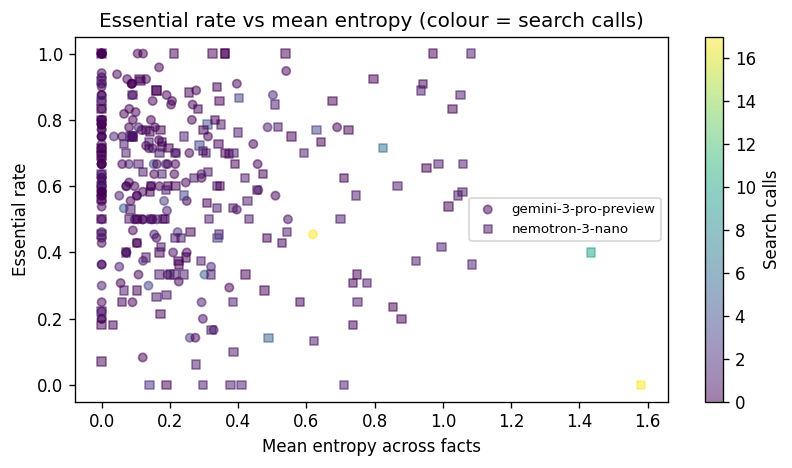

In [6]:
entropy_df = df.groupby(['problem', 'model']).agg(
    essential_rate=('is_essential', 'mean'),
    mean_entropy=('entropy', 'mean'),
    search_calls=('search_calls', 'first'),
).reset_index()

fig, ax = plt.subplots(figsize=(7, 4))
for model, grp in entropy_df.groupby('model'):
    sc = ax.scatter(grp['mean_entropy'], grp['essential_rate'],
                    c=grp['search_calls'], cmap='viridis',
                    alpha=0.5, s=25, label=model, marker='o' if 'gemini' in model else 's')
plt.colorbar(sc, ax=ax, label='Search calls')
ax.set_xlabel('Mean entropy across facts')
ax.set_ylabel('Essential rate')
ax.set_title('Essential rate vs mean entropy (colour = search calls)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Questions with the most non-essential facts

In [7]:
# Aggregate across both models
q_agg = (
    df.groupby('problem')['is_essential']
    .agg(essential='sum', total='count')
    .assign(non_essential=lambda x: x['total'] - x['essential'])
    .assign(essential_rate=lambda x: x['essential'] / x['total'])
    .sort_values('non_essential', ascending=False)
)

# Show top 10 by non-essential count with wrapped question text
top10 = q_agg.head(10).copy()
top10.index = [textwrap.shorten(q, width=80, placeholder='...') for q in top10.index]
top10[['essential', 'non_essential', 'total', 'essential_rate']].style\
    .background_gradient(subset=['non_essential'], cmap='Oranges')\
    .format({'essential_rate': '{:.0%}'})

,essential,non_essential,total,essential_rate
Please give me an exhaustive list of the elements and inorganic compounds...,71,31,102,70%
How to budget a biweekly Walmart paycheck?,2,26,28,7%
which of the warhammer 40k factions or races are most like the shoggoths on...,7,24,31,23%
okay so how do you think I should build this engine,5,24,29,17%
"Give me similar movies to The Notebook, where the guy is unashamedly in love...",7,23,30,23%
Give me a script (preferrably bash) or other means to connect a midi...,8,23,31,26%
How complex is this Event Socket Library? Is there a version for...,4,22,26,15%
I need a low risk way to sell some put options in such a way to generate some...,3,19,22,14%
How much did medieval arrows weigh. How much force did they typically have...,6,19,25,24%
How many supernova explosions have occurred since the alleged beginning of...,2,19,21,10%


## 7. Questions where models disagree most on essentialness

Mean cross-model disagreement on essentialness: 0.0%
Questions with >50% disagreement: 0


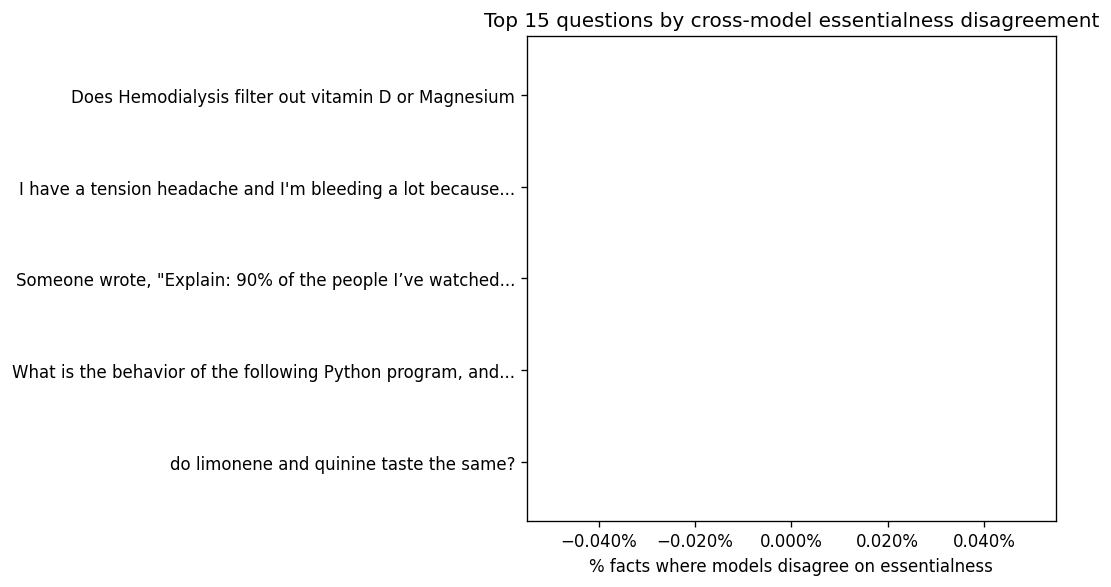

In [8]:
# For facts that appear in both models, compare is_essential label
model_compare = df.groupby(['problem', 'atomic_fact', 'model'])['is_essential'].first().unstack('model')
model_compare = model_compare.dropna()  # only facts present in both models
models = list(model_compare.columns)

if len(models) == 2:
    m1, m2 = models
    model_compare['disagree'] = model_compare[m1] != model_compare[m2]
    disagree_by_q = model_compare.groupby('problem')['disagree'].mean().sort_values(ascending=False)
    print(f"Mean cross-model disagreement on essentialness: {disagree_by_q.mean():.1%}")
    print(f"Questions with >50% disagreement: {(disagree_by_q > 0.5).sum()}")

    top_disagree = disagree_by_q.head(15)
    fig, ax = plt.subplots(figsize=(9, 5))
    labels = [textwrap.shorten(q, 60, placeholder='...') for q in top_disagree.index]
    ax.barh(labels[::-1], top_disagree.values[::-1] * 100, color='#9467BD')
    ax.set_xlabel('% facts where models disagree on essentialness')
    ax.set_title('Top 15 questions by cross-model essentialness disagreement')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.show()
else:
    print('Comparison requires exactly 2 models.')

## 8. Example facts: essential vs non-essential

In [9]:
def show_examples(model_name, n=4):
    sub = df[df['model'] == model_name]
    print(f"=== {model_name} ===")
    for label, grp in sub.groupby('is_essential'):
        tag = 'ESSENTIAL' if label else 'NON-ESSENTIAL'
        print(f"\n--- {tag} (sample of {n}) ---")
        sample = grp[['problem', 'atomic_fact', 'necessity_reasoning']].sample(n, random_state=0)
        for _, row in sample.iterrows():
            print(f"  Q : {textwrap.shorten(row['problem'], 90, placeholder='...')}")
            print(f"  F : {textwrap.shorten(row['atomic_fact'], 90, placeholder='...')}")
            print(f"  R : {textwrap.shorten(row['necessity_reasoning'], 90, placeholder='...')}")
            print()

for m in df['model'].unique():
    show_examples(m)

=== nemotron-3-nano ===

--- NON-ESSENTIAL (sample of 4) ---
  Q : How many people died because of communism? Is the 100 million number true
  F : Estimates of deaths due to communism depend on which countries are included in the count.
  R : This fact provides methodological context regarding how estimates are calculated rather...

  Q : Based on the model card, what did it cost to train GPT-OSS-120b and GPT-OSS-20b? Break...
  F : GPT-OSS-20b required roughly ten times fewer GPU-hours than GPT-OSS-120b.
  R : This fact describes a relative comparison between the two models' training requirements...

  Q : Are there some common things in these factors: Male 38 years old, anemia , reflux...
  F : Metabolic syndrome is an example of a systemic or neurovascular disturbance.
  R : The definition of metabolic syndrome as a systemic or neurovascular disturbance is a...

  Q : Which products with high-fructose corn syrup contain low-fat and few nutrients?
  F : Product ingredients vary by re

## 9. Manual question inspector

In [10]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

questions = sorted(df['problem'].unique())
models_available = sorted(df['model'].unique())

# ── widgets ───────────────────────────────────────────────────────────────────
idx_slider   = widgets.IntSlider(value=0, min=0, max=len(questions)-1, step=1,
                                  description='Question', continuous_update=False,
                                  layout=widgets.Layout(width='60%'))
prev_btn     = widgets.Button(description='◀ Prev', layout=widgets.Layout(width='80px'))
next_btn     = widgets.Button(description='Next ▶', layout=widgets.Layout(width='80px'))
model_toggle = widgets.ToggleButtons(options=models_available, description='Model',
                                      style={'button_width': '180px'})
out          = widgets.Output()

ESSENTIAL_STYLE    = 'background:#d4edda; border-left:4px solid #28a745; padding:8px 10px; margin:4px 0; border-radius:3px'
NONESSENTIAL_STYLE = 'background:#fff3cd; border-left:4px solid #ffc107; padding:8px 10px; margin:4px 0; border-radius:3px'

def render(idx, model):
    question = questions[idx]
    rows = df[(df['problem'] == question) & (df['model'] == model)]

    header = f"""
    <div style='font-size:13px; color:#666; margin-bottom:4px'>Question {idx+1} / {len(questions)} &nbsp;·&nbsp; model: <b>{model}</b></div>
    <div style='font-size:15px; font-weight:bold; background:#e8f0fe; padding:10px 12px;
                border-radius:4px; margin-bottom:10px; white-space:pre-wrap'>{question}</div>
    """

    if rows.empty:
        body = "<i>No facts for this model / question combination.</i>"
    else:
        meta_row  = rows.iloc[0]
        search_info = (
            f"<b>search calls:</b> {int(meta_row['search_calls'])}"
            if meta_row['has_search'] else "<b>no search</b>"
        )
        n_ess   = rows['is_essential'].sum()
        n_total = len(rows)
        meta_html = f"""
        <div style='font-size:12px; color:#555; margin-bottom:8px'>
            {search_info} &nbsp;·&nbsp;
            <b>essential:</b> {n_ess}/{n_total} ({n_ess/n_total:.0%})
        </div>
        """

        answer_html = f"""
        <details style='margin-bottom:10px'>
          <summary style='cursor:pointer; font-size:13px; font-weight:bold; color:#333'>▶ Model answer</summary>
          <div style='font-size:13px; white-space:pre-wrap; padding:8px; background:#f8f9fa;
                      border-radius:3px; margin-top:4px'>{meta_row['sampler_response']}</div>
        </details>
        """

        facts_html = ""
        for _, row in rows.sort_values('is_essential', ascending=False).iterrows():
            style = ESSENTIAL_STYLE if row['is_essential'] else NONESSENTIAL_STYLE
            tag   = '✅ Essential' if row['is_essential'] else '⚠️ Non-essential'
            attr  = ' · <span style="color:#1a73e8">from search</span>' \
                    if str(row.get('attributed_to_search', '')).lower() == 'true' else ''
            facts_html += f"""
            <div style='{style}'>
              <div style='font-size:11px; font-weight:bold; color:#555'>{tag}{attr}</div>
              <div style='font-size:13px; margin:3px 0'>{row['atomic_fact']}</div>
              <div style='font-size:11px; color:#777; font-style:italic'>{row['necessity_reasoning']}</div>
            </div>
            """

        body = meta_html + answer_html + facts_html

    with out:
        clear_output(wait=True)
        display(HTML(header + body))

def on_change(change):
    render(idx_slider.value, model_toggle.value)

def on_prev(_):
    idx_slider.value = max(0, idx_slider.value - 1)

def on_next(_):
    idx_slider.value = min(len(questions) - 1, idx_slider.value + 1)

idx_slider.observe(on_change, names='value')
model_toggle.observe(on_change, names='value')
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

nav = widgets.HBox([prev_btn, idx_slider, next_btn])
display(widgets.VBox([model_toggle, nav, out]))
render(0, model_toggle.value)

Essential rate by model × search attribution:
                                           Non-essential  Essential
model                attributed_to_search                          
gemini-3-pro-preview False                          39.3       60.7
                     True                           51.3       48.7
nemotron-3-nano      False                          48.3       51.7
                     True                           50.7       49.3


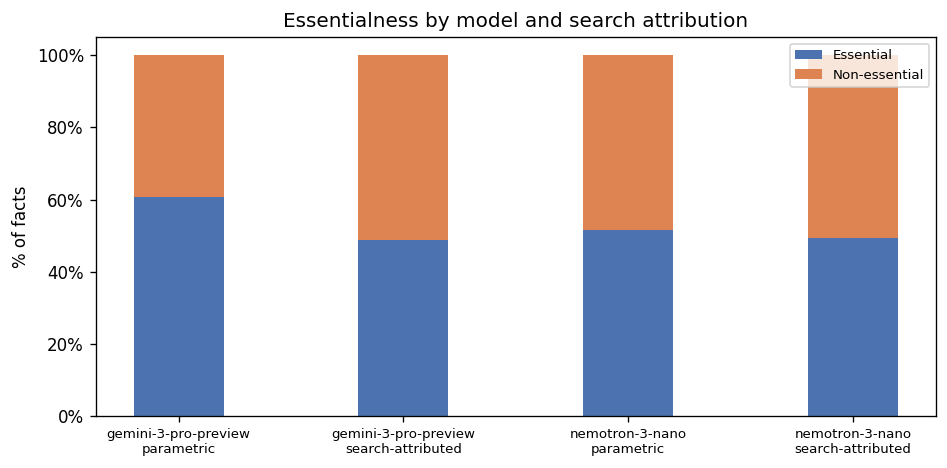

In [11]:
# Among facts that came from search: are they more often essential?
attr_df = df[df['has_search']].copy()
attr_df['attributed_to_search'] = attr_df['attributed_to_search'].astype(str).str.lower() == 'true'

if len(attr_df) > 0:
    cross = attr_df.groupby(['model', 'attributed_to_search', 'is_essential']).size().unstack(fill_value=0)
    cross.columns = ['Non-essential', 'Essential']
    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
    print("Essential rate by model × search attribution:")
    print(cross_pct.round(1).to_string())

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(cross_pct))
    width = 0.4
    ax.bar(x, cross_pct['Essential'], width, label='Essential', color='#4C72B0')
    ax.bar(x, cross_pct['Non-essential'], width, bottom=cross_pct['Essential'],
           label='Non-essential', color='#DD8452')
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{m}\n{'search-attributed' if s else 'parametric'}" for m, s in cross_pct.index],
        fontsize=8
    )
    ax.set_ylabel('% of facts')
    ax.set_title('Essentialness by model and search attribution')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('No search rows found — skipping.')